In [25]:
import os, sys
from os.path import join as pjoin
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

root_dir = "/accounts/campus/austin.zane/stat-genie"

os.chdir(root_dir)
sys.path.insert(0, root_dir)

analysis_dir = pjoin(root_dir, "outputs", "analysis")
pairwise_eval_dir = pjoin(root_dir, "outputs", "pairwise_eval")


perturbation_mapping = {
    0: "add_features",
    1: "anonymize",
    2: "noperturb",
    3: "replace_with_rvs",
    4: "shuffle_names",
    5: "positive_leading_statement",
    6: "negative_leading_statement",
    7: "replace_and_positive_statement"
}

perturbation_to_int = {
    "add_features": 0,
    "anonymize": 1,
    "noperturb": 2,
    "replace_with_rvs": 3,
    "shuffle_names": 4,
    "positive_leading_statement": 5,
    "negative_leading_statement": 6,
    "replace_and_positive_statement": 7
}

perturbations = perturbation_to_int.keys()
baseline_perturbation = "noperturb"
baseline_idx = perturbation_to_int[baseline_perturbation]
baseline_within_string = f"within:{baseline_perturbation}"

all_datasets = os.listdir(analysis_dir)
datasets = [d for d in all_datasets if os.path.exists(pjoin(pairwise_eval_dir, d))]
print(f"{len(datasets)} datasets: {datasets}")

10 datasets: ['teachingratings', 'amtl', 'mortgage', 'panda_nuts', 'caschools', 'hurricane', 'crofoot', 'affairs', 'soccer', 'boxes']


In [26]:
for dataset in datasets:
    if not os.path.exists(pjoin(pairwise_eval_dir, dataset)):
        continue
    try:
        job_id = os.listdir(pjoin(pairwise_eval_dir, dataset))[0]
        with open(pjoin(pairwise_eval_dir, dataset, job_id, "pairwise_similarities.json"), "r") as f:
            pairwise_eval = json.load(f)

        print(dataset)
        diag_dict = {}

        for k_i, v_i in pairwise_eval.items():
            if k_i[0] != k_i[2]:
                continue
            i_list = []
            for k_j, v_j in v_i.items():
                if k_j[0] != k_j[2]:
                    continue
                i_list.append(v_j['overall_similarity'])
                if v_j['overall_similarity'] < 5.0:
                    print(f'Low score for identical analyses: {v_j["overall_similarity"]}')
            diag_dict[k_i] = i_list
    except (FileNotFoundError, IndexError, KeyError) as e:
        print(f"Skipping {dataset}")
        continue

teachingratings
amtl
mortgage
panda_nuts
caschools
hurricane
crofoot
affairs
soccer
boxes


In [27]:
pairwise_eval

{'0_0': {'0_0': {'Independent Variables Similarity Score': 5,
   'Control Variables Similarity Score': 5,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 5,
   'conclusions': 5,
   'overall_similarity': 5.0},
  '0_1': {'Independent Variables Similarity Score': 5,
   'Control Variables Similarity Score': 4,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 3,
   'conclusions': 5,
   'overall_similarity': 4.4},
  '0_2': {'Independent Variables Similarity Score': 4,
   'Control Variables Similarity Score': 4,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 4,
   'conclusions': 2,
   'overall_similarity': 3.8},
  '0_3': {'Independent Variables Similarity Score': 4,
   'Control Variables Similarity Score': 4,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 3,
   'conclusions': 2,
   'overall_similarity': 3.6},
  '0_4': {'Independent Variables Similarity Score': 5,
   'Control Variables Simi

In [28]:
# Parse pairwise evaluation JSON files
# Keys: 'i_j' = perturbation i vs j, 'k_l' = run k vs run l

rows = []

for dataset in datasets:
    if not os.path.exists(pjoin(pairwise_eval_dir, dataset)):
        continue
    try:
        job_id = os.listdir(pjoin(pairwise_eval_dir, dataset))[0]
        json_path = pjoin(pairwise_eval_dir, dataset, job_id, "pairwise_similarities.json")
        
        with open(json_path, "r") as f:
            pairwise_eval = json.load(f)
    except (FileNotFoundError, IndexError, KeyError) as e:
        print(f"Skipping {dataset}")
        continue
    
    for pert_key, inner_dict in pairwise_eval.items():
        parts_pert = pert_key.split('_')
        perturbation_i = int(parts_pert[0])
        perturbation_j = int(parts_pert[1])
        
        for run_key, scores_dict in inner_dict.items():
            parts_run = run_key.split('_')
            run_i = int(parts_run[0])
            run_j = int(parts_run[1])
            
            row = {
                'dataset': dataset,
                'perturbation_i': perturbation_i,
                'perturbation_j': perturbation_j,
                'run_i': run_i,
                'run_j': run_j,
                'iv_score': scores_dict.get('Independent Variables Similarity Score'),
                'cv_score': scores_dict.get('Control Variables Similarity Score'),
                'model_score': scores_dict.get('Model Similarity Score'),
                'conclusion_score': scores_dict.get('conclusions'),
                'overall_score': scores_dict.get('overall_similarity')
            }
            rows.append(row)

df_pairwise = pd.DataFrame(rows)

def get_perturbation_pair_type(row):
    pert_i = row['perturbation_i']
    pert_j = row['perturbation_j']
    name_i = perturbation_mapping[pert_i]
    name_j = perturbation_mapping[pert_j]
    
    if pert_i == pert_j:
        return f'within:{name_i}'
    elif pert_i == baseline_idx:
        return f'baseline_vs:{name_j}'
    elif pert_j == baseline_idx:
        return f'baseline_vs:{name_i}'
    else:
        return f'between:{name_i}__{name_j}'

df_pairwise['perturbation_pair_type'] = df_pairwise.apply(get_perturbation_pair_type, axis=1)

print(f"{len(df_pairwise)} rows")
print(df_pairwise.head())
print(f"\n{df_pairwise['perturbation_pair_type'].value_counts()}")


5400 rows
           dataset  perturbation_i  perturbation_j  run_i  run_j  iv_score  \
0  teachingratings               0               0      0      0         5   
1  teachingratings               0               0      0      1         5   
2  teachingratings               0               0      0      2         4   
3  teachingratings               0               0      0      3         4   
4  teachingratings               0               0      0      4         5   

   cv_score  model_score  conclusion_score  overall_score  \
0         5            5                 5            5.0   
1         5            5                 5            5.0   
2         4            3                 4            4.0   
3         5            3                 4            4.2   
4         5            5                 1            4.2   

  perturbation_pair_type  
0    within:add_features  
1    within:add_features  
2    within:add_features  
3    within:add_features  
4    within:add_fea

In [29]:
df_pairwise.loc[(df_pairwise['perturbation_i'] == df_pairwise['perturbation_j']) & (df_pairwise['run_i'] == df_pairwise['run_j'])]

,dataset,perturbation_i,perturbation_j,run_i,run_j,iv_score,cv_score,model_score,conclusion_score,overall_score,perturbation_pair_type
0,teachingratings,0,0,0,0,5,5,5,5,5.0,within:add_features
5,teachingratings,0,0,1,1,5,5,5,5,5.0,within:add_features
9,teachingratings,0,0,2,2,5,5,5,5,5.0,within:add_features
12,teachingratings,0,0,3,3,5,5,5,5,5.0,within:add_features
14,teachingratings,0,0,4,4,5,5,5,5,5.0,within:add_features
...,...,...,...,...,...,...,...,...,...,...,...
5385,boxes,7,7,0,0,5,5,5,5,5.0,within:replace_and_positive_statement
5390,boxes,7,7,1,1,5,5,5,5,5.0,within:replace_and_positive_statement
5394,boxes,7,7,2,2,5,5,5,5,5.0,within:replace_and_positive_statement
5397,boxes,7,7,3,3,5,5,5,5,5.0,within:replace_and_positive_statement


In [30]:
print(df_pairwise.head())

           dataset  perturbation_i  perturbation_j  run_i  run_j  iv_score  \
0  teachingratings               0               0      0      0         5   
1  teachingratings               0               0      0      1         5   
2  teachingratings               0               0      0      2         4   
3  teachingratings               0               0      0      3         4   
4  teachingratings               0               0      0      4         5   

   cv_score  model_score  conclusion_score  overall_score  \
0         5            5                 5            5.0   
1         5            5                 5            5.0   
2         4            3                 4            4.0   
3         5            3                 4            4.2   
4         5            5                 1            4.2   

  perturbation_pair_type  
0    within:add_features  
1    within:add_features  
2    within:add_features  
3    within:add_features  
4    within:add_features  


In [31]:
score_cols = [
    "iv_score",
    "cv_score",
    "model_score",
    "conclusion_score",
    # "overall_score",
]

long_df = df_pairwise.melt(
    id_vars=["dataset", "perturbation_pair_type"],
    value_vars=score_cols,
    var_name="step",
    value_name="score",
)

long_df["step"] = long_df["step"].str.replace("_score", "")


long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"].astype("category")
)
long_df["step"] = long_df["step"].astype("category")
long_df["dataset"] = long_df["dataset"].astype("category")


long_df["perturbation_pair_type"] = long_df["perturbation_pair_type"].astype("category")

baseline = baseline_within_string

new_order = (
    [baseline] +
    [c for c in long_df["perturbation_pair_type"].cat.categories if c != baseline]
)

long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"]
    .cat.reorder_categories(new_order, ordered=False)
)


long_df["step"] = long_df["step"].astype("category")

step_ref = "conclusion"
step_order = (
    [step_ref] +
    [s for s in long_df["step"].cat.categories if s != step_ref]
)

long_df["step"] = long_df["step"].cat.reorder_categories(step_order, ordered=False)



In [32]:
long_df

,dataset,perturbation_pair_type,step,score
0,teachingratings,within:add_features,iv,5
1,teachingratings,within:add_features,iv,5
2,teachingratings,within:add_features,iv,4
3,teachingratings,within:add_features,iv,4
4,teachingratings,within:add_features,iv,5
...,...,...,...,...
21595,boxes,within:replace_and_positive_statement,conclusion,1
21596,boxes,within:replace_and_positive_statement,conclusion,1
21597,boxes,within:replace_and_positive_statement,conclusion,5
21598,boxes,within:replace_and_positive_statement,conclusion,4


In [9]:
import statsmodels.formula.api as smf

model = smf.ols(
    "score ~ C(step) * C(perturbation_pair_type) + C(dataset)",
    data=long_df,
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     76.86
Date:                Fri, 23 Jan 2026   Prob (F-statistic):               0.00
Time:                        08:17:44   Log-Likelihood:                -28690.
No. Observations:               21600   AIC:                         5.769e+04
Df Residuals:                   21447   BIC:                         5.891e+04
Df Model:                         152                                         
Covariance Type:            nonrobust                                         
                                                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [10]:
# Create bar plots for coefficients with confidence intervals
coef_df = pd.DataFrame({
    'coef': model.params,
    'std_err': model.bse,
    'lower_ci': model.conf_int()[0],
    'upper_ci': model.conf_int()[1]
})

# Function to plot specific coefficients
def plot_coefficients(coef_names, title="Coefficients with 95% Confidence Intervals", figsize=(12, 6)):
    """
    Plot bar plots for specified coefficients with confidence intervals.
    
    Parameters:
    coef_names: list of coefficient names to plot 
    title: plot title
    figsize: figure size tuple
    """
    if isinstance(coef_names, str):
        coef_names = [coef_names]
    
    matching_coefs = []
    for name in coef_names:
        matches = [c for c in coef_df.index if name in c]
        matching_coefs.extend(matches)
    
    if not matching_coefs:
        print(f"No coefficients found matching: {coef_names}")
        return
    
    plot_data = coef_df.loc[matching_coefs].copy()
    plot_data = plot_data.sort_values('coef')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_data))
    
    colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    bars = ax.barh(y_pos, plot_data['coef'], color=colors, alpha=0.7)
    
    errors_lower = plot_data['coef'] - plot_data['lower_ci']
    errors_upper = plot_data['upper_ci'] - plot_data['coef']
    ax.errorbar(plot_data['coef'], y_pos, 
                xerr=[errors_lower, errors_upper],
                fmt='none', color='black', capsize=3, capthick=1.5)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.set_xlabel('Coefficient Estimate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return plot_data


Step effects:


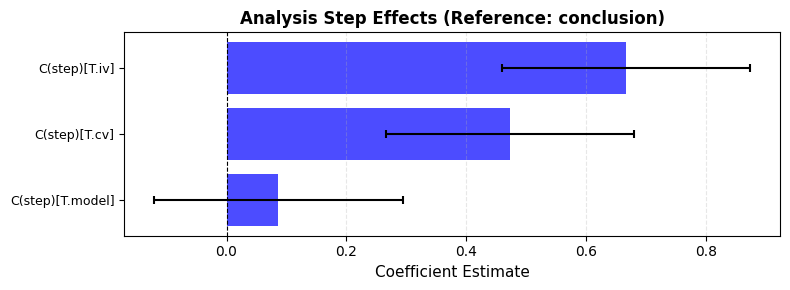

In [33]:
def plot_coefficients(coef_names, title="Coefficients with 95% Confidence Intervals", figsize=(12, 6), color=None):
    """
    Plot bar plots for specified coefficients with confidence intervals.
    
    Parameters:
    coef_names: list of coefficient names to plot (exact names or partial matches)
    title: plot title
    figsize: figure size tuple
    color: color specification for bars. Can be:
        - None: uses red for negative, blue for positive coefficients
        - string: single color for all bars
        - list: colors for each bar (will cycle if shorter than number of bars)
    """

    if isinstance(coef_names, str):
        coef_names = [coef_names]
    

    matching_coefs = []
    for name in coef_names:

        if name in coef_df.index:
            matching_coefs.append(name)
        else:
            matches = [c for c in coef_df.index if name in c]
            matching_coefs.extend(matches)
    

    matching_coefs = list(dict.fromkeys(matching_coefs))
    
    if not matching_coefs:
        print(f"No coefficients found matching: {coef_names}")
        return
    
    plot_data = coef_df.loc[matching_coefs].copy()
    plot_data = plot_data.sort_values('coef')
    

    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_data))
    
    if color is None:
        colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    elif isinstance(color, str):
        colors = color
    elif isinstance(color, (list, tuple, np.ndarray)):
        import itertools
        colors = list(itertools.islice(itertools.cycle(color), len(plot_data)))
    else:
        colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    
    bars = ax.barh(y_pos, plot_data['coef'], color=colors, alpha=0.7)
    
    errors_lower = plot_data['coef'] - plot_data['lower_ci']
    errors_upper = plot_data['upper_ci'] - plot_data['coef']
    ax.errorbar(plot_data['coef'], y_pos, 
                xerr=[errors_lower, errors_upper],
                fmt='none', color='black', capsize=3, capthick=1.5)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.set_xlabel('Coefficient Estimate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return plot_data

def get_main_effects(pattern):
    """Get main effects only (exclude interactions)."""
    matches = [c for c in coef_df.index if pattern in c]
    main_effects = [c for c in matches if c.count('C(') == 1]
    return main_effects

print("Step effects:")
step_main_effects = get_main_effects('C(step)[T.')
step_coefs = plot_coefficients(step_main_effects, 
                                title="Analysis Step Effects (Reference: conclusion)",
                                figsize=(8, 3))

Perturbation pair type effects:


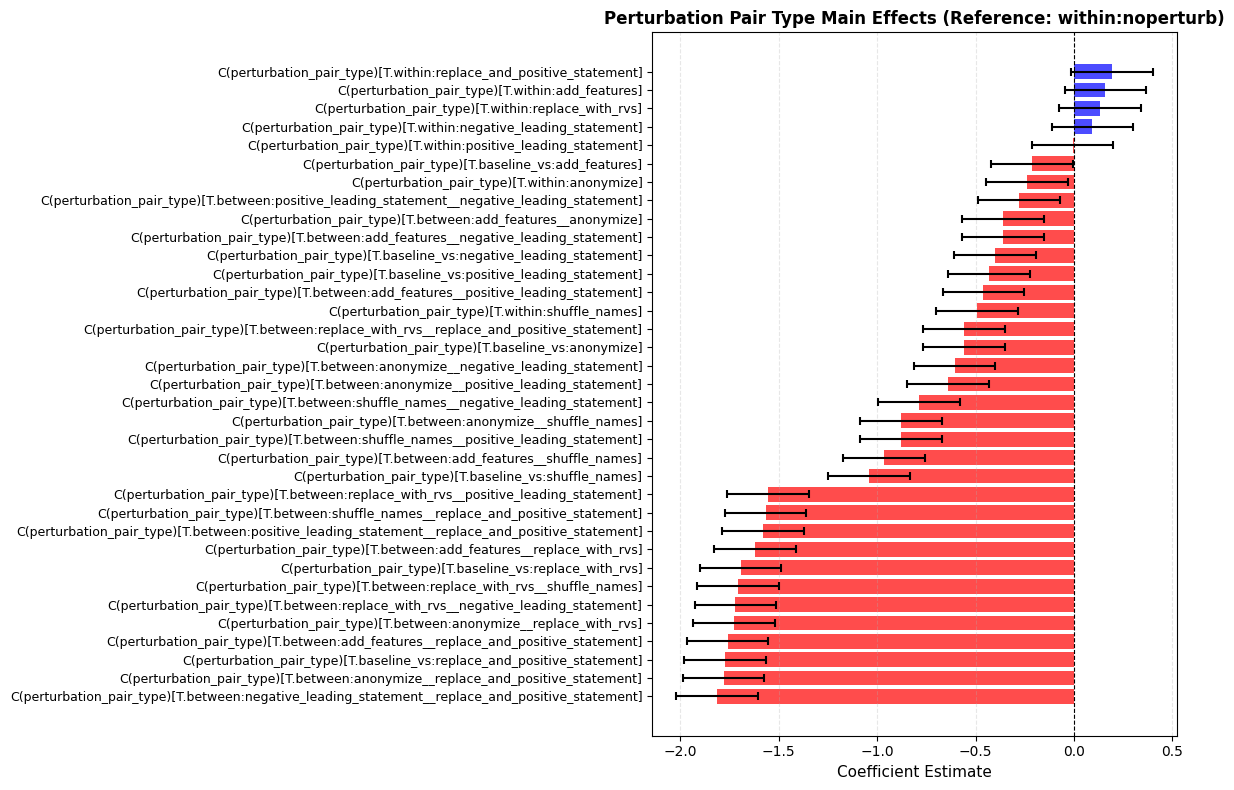

In [34]:
print("Perturbation pair type effects:")
pert_main_effects = get_main_effects('C(perturbation_pair_type)[T.')
pert_coefs = plot_coefficients(pert_main_effects, 
                                title="Perturbation Pair Type Main Effects (Reference: within:noperturb)",
                                figsize=(12, 8))

Within perturbation effects:


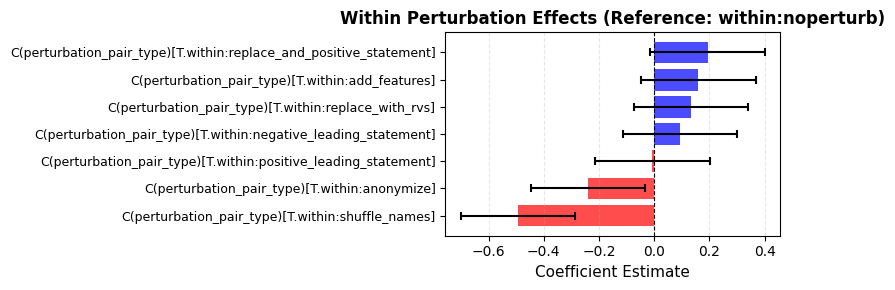

In [35]:
print("Within perturbation effects:")
pert_main_effects_within = get_main_effects('C(perturbation_pair_type)[T.within')
pert_coefs = plot_coefficients(pert_main_effects_within, 
                                title="Within Perturbation Effects (Reference: within:noperturb)",
                                figsize=(8, 3))

Baseline vs perturbation effects:


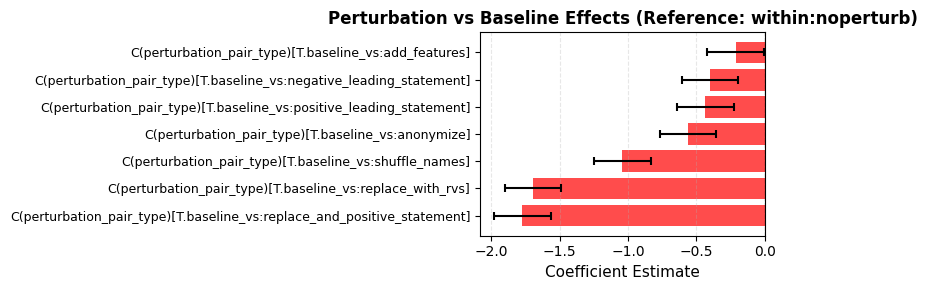

In [36]:
print("Baseline vs perturbation effects:")
pert_main_effects_baseline_vs = get_main_effects('C(perturbation_pair_type)[T.baseline_vs')
pert_coefs = plot_coefficients(pert_main_effects_baseline_vs, 
                                title="Perturbation vs Baseline Effects (Reference: within:noperturb)",
                                figsize=(8, 3))

Between perturbation effects:


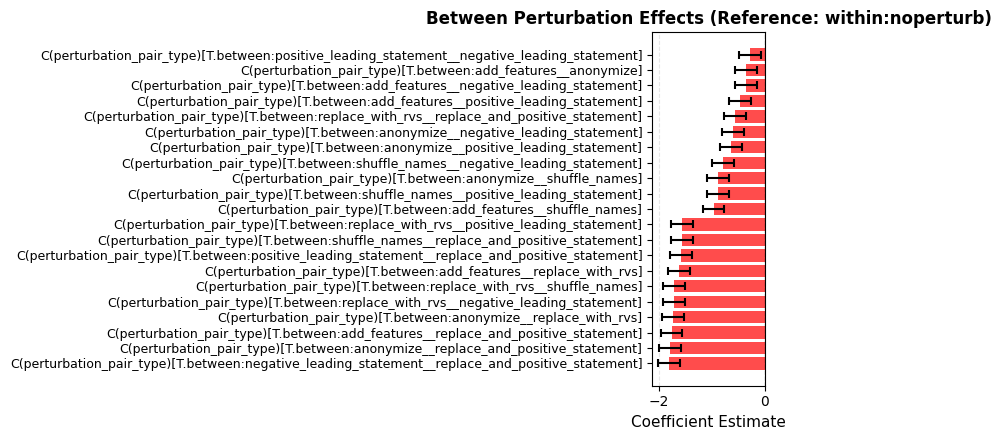

In [37]:
print("Between perturbation effects:")
pert_main_effects_between = get_main_effects('C(perturbation_pair_type)[T.between')
pert_coefs = plot_coefficients(pert_main_effects_between, 
                                title="Between Perturbation Effects (Reference: within:noperturb)",
                                figsize=(8, 4.5))

# Heatmap

In [ ]:
baseline = (
    long_df[long_df["perturbation_pair_type"] == baseline_within_string]
    .groupby(["dataset", "step"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "baseline_score"})
)
merged = long_df.merge(
    baseline,
    on=["dataset", "step"],
    how="left"
)

merged["delta"] = merged["score"] - merged["baseline_score"]

heatmap_df = (
    merged.groupby(["step", "perturbation_pair_type"])["delta"]
    .mean()
    .unstack()
)

mask = heatmap_df.columns.str.startswith("between")
heatmap_df_filtered = heatmap_df.loc[:, ~mask]



In [17]:
print(heatmap_df_filtered)

perturbation_pair_type  within:noperturb  baseline_vs:add_features  \
step                                                                 
conclusion                 -1.480297e-17                 -0.213333   
cv                          2.368476e-17                 -0.360000   
iv                          0.000000e+00                 -0.180000   
model                      -1.776357e-17                 -0.546667   

perturbation_pair_type  baseline_vs:anonymize  \
step                                            
conclusion                          -0.560000   
cv                                  -0.186667   
iv                                  -0.080000   
model                               -0.373333   

perturbation_pair_type  baseline_vs:negative_leading_statement  \
step                                                             
conclusion                                           -0.400000   
cv                                                   -0.186667   
iv                  

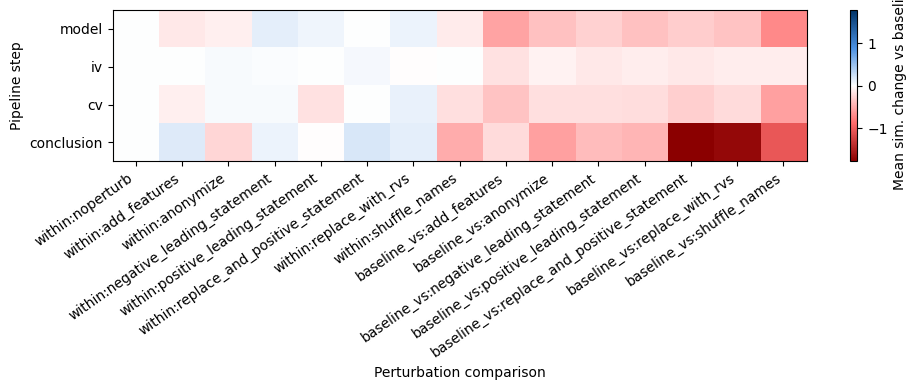

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

non_baseline_perturbations = sorted([p for p in perturbation_to_int.keys() if p != baseline_perturbation])

desired_order = [baseline_within_string]
for pert_name in non_baseline_perturbations:
    desired_order.append(f'within:{pert_name}')
for pert_name in non_baseline_perturbations:
    desired_order.append(f'baseline_vs:{pert_name}')

available_cols = [col for col in desired_order if col in heatmap_df_filtered.columns]
heatmap_df_filtered = heatmap_df_filtered[available_cols]

colors = ['#8b0000', '#ff6b6b', '#ffffff', '#4a90e2', '#003366']
cmap = LinearSegmentedColormap.from_list('red_white_blue', colors, N=256)

data = heatmap_df_filtered.values
vmin, vmax = data.min(), data.max()
abs_max = max(abs(vmin), abs(vmax))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(
    heatmap_df_filtered.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax.set_xticks(np.arange(heatmap_df_filtered.shape[1]))
ax.set_yticks(np.arange(heatmap_df_filtered.shape[0]))

ax.set_xticklabels(heatmap_df_filtered.columns, rotation=35, ha="right")
ax.set_yticklabels(heatmap_df_filtered.index)

ax.set_xlabel("Perturbation comparison")
ax.set_ylabel("Pipeline step")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()


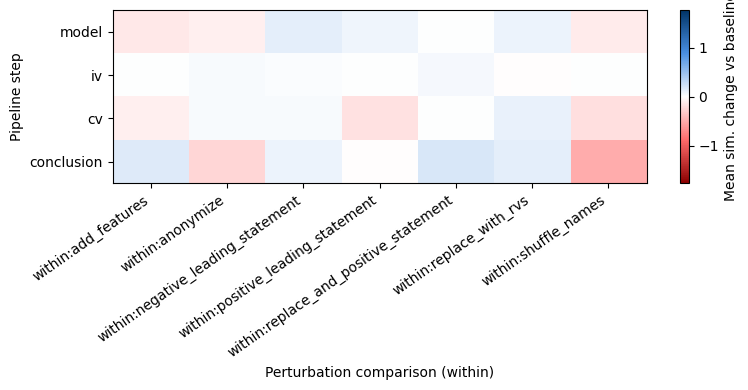

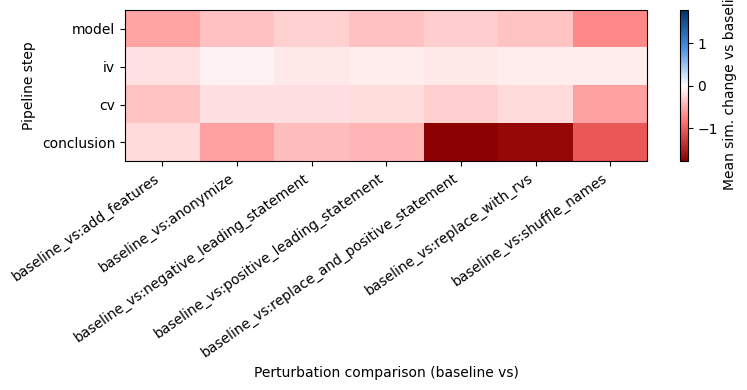

In [ ]:
# Split into within and baseline_vs heatmaps
within_cols = [col for col in heatmap_df_filtered.columns if col.startswith('within:')]
baseline_vs_cols = [col for col in heatmap_df_filtered.columns if col.startswith('baseline_vs:')]

heatmap_within = heatmap_df_filtered[within_cols]
heatmap_baseline_vs = heatmap_df_filtered[baseline_vs_cols]

heatmap_within = heatmap_within.drop(columns=[baseline_within_string], errors='ignore')

fig1, ax1 = plt.subplots(figsize=(8, 4))

im1 = ax1.imshow(
    heatmap_within.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax1.set_xticks(np.arange(heatmap_within.shape[1]))
ax1.set_yticks(np.arange(heatmap_within.shape[0]))
ax1.set_xticklabels(heatmap_within.columns, rotation=35, ha="right")
ax1.set_yticklabels(heatmap_within.index)
ax1.set_xlabel("Perturbation comparison (within)")
ax1.set_ylabel("Pipeline step")

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()

# Create second figure: "baseline_vs:" heatmap
fig2, ax2 = plt.subplots(figsize=(8, 4))

im2 = ax2.imshow(
    heatmap_baseline_vs.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax2.set_xticks(np.arange(heatmap_baseline_vs.shape[1]))
ax2.set_yticks(np.arange(heatmap_baseline_vs.shape[0]))
ax2.set_xticklabels(heatmap_baseline_vs.columns, rotation=35, ha="right")
ax2.set_yticklabels(heatmap_baseline_vs.index)
ax2.set_xlabel("Perturbation comparison (baseline vs)")
ax2.set_ylabel("Pipeline step")

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()

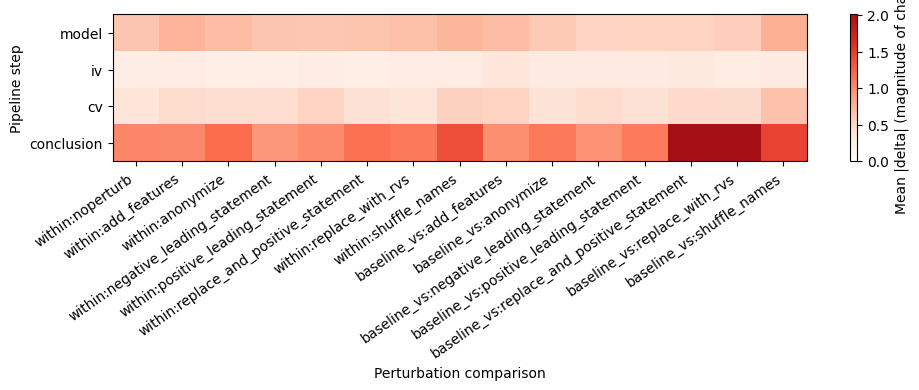

In [ ]:
# Mean absolute delta (magnitude regardless of direction)
heatmap_abs_df = (
    merged.groupby(["step", "perturbation_pair_type"])["delta"]
    .apply(lambda x: np.abs(x).mean())
    .unstack()
)

mask_abs = heatmap_abs_df.columns.str.startswith("between")
heatmap_abs_filtered = heatmap_abs_df.loc[:, ~mask_abs]

available_cols_abs = [col for col in desired_order if col in heatmap_abs_filtered.columns]
heatmap_abs_filtered = heatmap_abs_filtered[available_cols_abs]

colors_abs = ['#ffffff', '#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
cmap_abs = LinearSegmentedColormap.from_list('white_to_dark', colors_abs, N=256)

data_abs = heatmap_abs_filtered.values
vmin_abs, vmax_abs = 0, data_abs.max()

fig, ax = plt.subplots(figsize=(10, 4))

im_abs = ax.imshow(
    heatmap_abs_filtered.values,
    aspect="auto",
    origin="lower",
    cmap=cmap_abs,
    vmin=vmin_abs,
    vmax=vmax_abs,
)

ax.set_xticks(np.arange(heatmap_abs_filtered.shape[1]))
ax.set_yticks(np.arange(heatmap_abs_filtered.shape[0]))

ax.set_xticklabels(heatmap_abs_filtered.columns, rotation=35, ha="right")
ax.set_yticklabels(heatmap_abs_filtered.index)

ax.set_xlabel("Perturbation comparison")
ax.set_ylabel("Pipeline step")

cbar_abs = plt.colorbar(im_abs, ax=ax)
cbar_abs.set_label("Mean |delta| (magnitude of change)")

plt.tight_layout()
plt.show()

In [40]:
# Compare replace_with_rvs vs replace_and_positive_statement
pert1 = "replace_with_rvs"
pert2 = "replace_and_positive_statement"

# Get mean deltas for each vs baseline
pert1_vs_baseline = merged[
    merged['perturbation_pair_type'] == f'baseline_vs:{pert1}'
].groupby('step')['delta'].mean()

pert2_vs_baseline = merged[
    merged['perturbation_pair_type'] == f'baseline_vs:{pert2}'
].groupby('step')['delta'].mean()

# Get within perturbation differences from baseline
pert1_within = merged[
    merged['perturbation_pair_type'] == f'within:{pert1}'
].groupby('step')['delta'].mean()

pert2_within = merged[
    merged['perturbation_pair_type'] == f'within:{pert2}'
].groupby('step')['delta'].mean()

# Direct comparison between the two
between_comparison = merged[
    merged['perturbation_pair_type'].isin([f'between:{pert1}__{pert2}', f'between:{pert2}__{pert1}'])
].groupby('step')['delta'].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    f'{pert1} vs baseline': pert1_vs_baseline,
    f'{pert2} vs baseline': pert2_vs_baseline,
    f'within:{pert1}': pert1_within,
    f'within:{pert2}': pert2_within,
    f'{pert1} vs {pert2}': between_comparison,
    'difference': pert1_vs_baseline - pert2_vs_baseline
})

print(f"Comparison: {pert1} vs {pert2}")
print(comparison_df)
comparison_df

Comparison: replace_with_rvs vs replace_and_positive_statement
            replace_with_rvs vs baseline  \
step                                       
conclusion                     -1.693333   
cv                             -0.220000   
iv                             -0.100000   
model                          -0.346667   

            replace_and_positive_statement vs baseline  \
step                                                     
conclusion                                   -1.773333   
cv                                           -0.280000   
iv                                           -0.133333   
model                                        -0.293333   

            within:replace_with_rvs  within:replace_and_positive_statement  \
step                                                                         
conclusion                 0.133333                           1.933333e-01   
cv                         0.106667                           2.368476e-17   
iv         

,replace_with_rvs vs baseline,replace_and_positive_statement vs baseline,within:replace_with_rvs,within:replace_and_positive_statement,replace_with_rvs vs replace_and_positive_statement,difference
step,,,,,,
conclusion,-1.693333,-1.773333,0.133333,1.933333e-01,-0.560000,0.080000
cv,-0.220000,-0.280000,0.106667,2.368476e-17,-0.180000,0.060000
iv,-0.100000,-0.133333,-0.013333,4.666667e-02,-0.173333,0.033333
model,-0.346667,-0.293333,0.086667,1.333333e-02,-0.333333,-0.053333


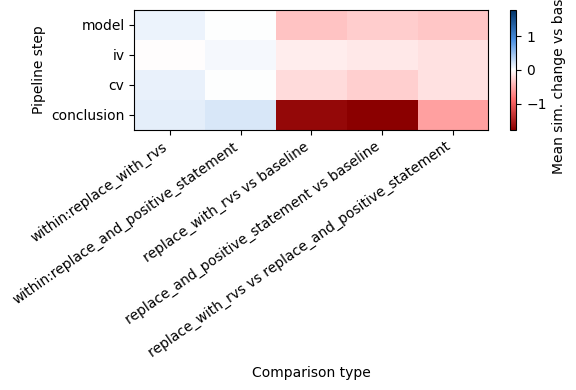

In [42]:
# Heatmap comparing replace_with_rvs and replace_and_positive_statement
pert1 = "replace_with_rvs"
pert2 = "replace_and_positive_statement"

# Get columns from filtered heatmap (within and baseline_vs)
heatmap_comparison = heatmap_df_filtered[[
    f'within:{pert1}',
    f'within:{pert2}',
    f'baseline_vs:{pert1}',
    f'baseline_vs:{pert2}'
]].copy()

# Get between comparison from full heatmap (it was filtered out earlier)
between_col = None
if f'between:{pert1}__{pert2}' in heatmap_df.columns:
    between_col = f'between:{pert1}__{pert2}'
elif f'between:{pert2}__{pert1}' in heatmap_df.columns:
    between_col = f'between:{pert2}__{pert1}'

if between_col:
    heatmap_comparison[between_col] = heatmap_df[between_col]

# Reorder and rename columns
if between_col:
    heatmap_comparison = heatmap_comparison[[
        f'within:{pert1}',
        f'within:{pert2}',
        f'baseline_vs:{pert1}',
        f'baseline_vs:{pert2}',
        between_col
    ]]
    
    heatmap_comparison.columns = [
        f'within:{pert1}',
        f'within:{pert2}',
        f'{pert1} vs baseline',
        f'{pert2} vs baseline',
        f'{pert1} vs {pert2}'
    ]
else:
    # Fallback if between comparison doesn't exist
    heatmap_comparison.columns = [
        f'within:{pert1}',
        f'within:{pert2}',
        f'{pert1} vs baseline',
        f'{pert2} vs baseline'
    ]

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(
    heatmap_comparison.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax.set_xticks(np.arange(heatmap_comparison.shape[1]))
ax.set_yticks(np.arange(heatmap_comparison.shape[0]))

ax.set_xticklabels(heatmap_comparison.columns, rotation=35, ha="right")
ax.set_yticklabels(heatmap_comparison.index)

ax.set_xlabel("Comparison type")
ax.set_ylabel("Pipeline step")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()

In [55]:
# # Print conclusions for replace_with_rvs and replace_and_positive_statement
# pert1 = "replace_with_rvs"
# pert2 = "replace_and_positive_statement"

# import glob

# for pert_name in [pert1, pert2]:
#     print(f"\n{'='*80}")
#     print(f"{pert_name.upper()}")
#     print(f"{'='*80}\n")
    
#     for dataset in datasets:
#         output_dir = pjoin(analysis_dir, dataset, f"{pert_name}_output")
        
#         if not os.path.exists(output_dir):
#             continue
        
#         conclusion_files = sorted(glob.glob(pjoin(output_dir, "final_conclusion_*.txt")))
        
#         if not conclusion_files:
#             continue
        
#         print(f"\nDataset: {dataset}")
#         print("-" * 80)
        
#         for i, file_path in enumerate(conclusion_files):
#             with open(file_path, 'r') as f:
#                 content = f.read().strip()
#                 print(f"\nRun {i}:")
#                 print(content)
#                 print()

In [56]:
pert1 = "replace_with_rvs"
pert2 = "replace_and_positive_statement"
baseline_pert = "noperturb"

import glob

all_unique_answers = set()
for pert_name in [baseline_pert, pert1, pert2]:
    for dataset in datasets:
        output_dir = pjoin(analysis_dir, dataset, f"{pert_name}_output")
        if not os.path.exists(output_dir):
            continue
        conclusion_files = sorted(glob.glob(pjoin(output_dir, "final_conclusion_*.txt")))
        for file_path in conclusion_files:
            try:
                with open(file_path, 'r') as f:
                    content = json.load(f)
                    if 'answer' in content:
                        all_unique_answers.add(content['answer'])
            except (json.JSONDecodeError, KeyError):
                continue

proportions_dict = {}
for pert_name in [baseline_pert, pert1, pert2]:
    all_answers = []
    for dataset in datasets:
        output_dir = pjoin(analysis_dir, dataset, f"{pert_name}_output")
        if not os.path.exists(output_dir):
            continue
        conclusion_files = sorted(glob.glob(pjoin(output_dir, "final_conclusion_*.txt")))
        for file_path in conclusion_files:
            try:
                with open(file_path, 'r') as f:
                    content = json.load(f)
                    if 'answer' in content:
                        all_answers.append(content['answer'])
            except (json.JSONDecodeError, KeyError):
                continue
    
    if all_answers:
        answer_counts = pd.Series(all_answers).value_counts()
        proportions_dict[pert_name] = answer_counts / len(all_answers)
    else:
        proportions_dict[pert_name] = pd.Series(dtype=float)

answer_proportions_df = pd.DataFrame(proportions_dict).fillna(0)

desired_order = ['Yes', 'No', 'Not enough information']
existing_rows = [row for row in desired_order if row in answer_proportions_df.index]
other_rows = [row for row in answer_proportions_df.index if row not in desired_order]
answer_proportions_df = answer_proportions_df.reindex(existing_rows + other_rows)

answer_proportions_df
# print()
# for pert_name in [baseline_pert, pert1, pert2]:
#     total = sum([len(glob.glob(pjoin(analysis_dir, d, f"{pert_name}_output", "final_conclusion_*.txt"))) 
#                  for d in datasets if os.path.exists(pjoin(analysis_dir, d, f"{pert_name}_output"))])
#     print(f"{pert_name}: {total} runs")

,noperturb,replace_with_rvs,replace_and_positive_statement
Yes,0.46,0.14,0.08
No,0.32,0.76,0.84
Not enough information,0.22,0.10,0.08
